# Simple Logistic Regression

This notebook covers the fundamentals of logistic regression for binary classification tasks. We'll explore both implementing logistic regression from scratch and using scikit-learn's implementation.

## 1. Import Required Libraries

In [1]:
# Import basic libraries for data manipulation and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# For machine learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_breast_cancer

# For displaying plots inline
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Understanding Logistic Regression

Logistic regression is a statistical method used for binary classification problems. Unlike linear regression which outputs continuous values, logistic regression outputs a probability value between 0 and 1, which is then classified as 0 or 1 based on a threshold (usually 0.5).

### The Sigmoid Function

The key component of logistic regression is the sigmoid function (also known as the logistic function):

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

Where $z = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + ... + \beta_n x_n$ is the linear combination of features and their corresponding weights.

The sigmoid function maps any real-valued number to a value between 0 and 1, making it suitable for modeling probabilities.

### Difference from Linear Regression

- Linear regression predicts continuous values
- Logistic regression predicts probabilities for binary outcomes
- Logistic regression uses the sigmoid function to map predictions to probabilities
- Logistic regression uses maximum likelihood estimation instead of least squares

In [4]:
# # Visualize the sigmoid function
# def sigmoid(x):
#     return 1 / (1 + np.exp(-x))

# x = np.linspace(-10, 10, 1000)
# y = sigmoid(x)

# plt.figure(figsize=(10, 6))
# plt.plot(x, y, 'b-', linewidth=2)
# plt.grid(True)
# plt.title('Sigmoid (Logistic) Function', fontsize=15)
# plt.xlabel('z = β₀ + β₁x₁ + ... + βₙxₙ', fontsize=12)
# plt.ylabel('σ(z) = 1 / (1 + e^(-z))', fontsize=12)
# plt.axhline(y=0.5, color='r', linestyle='--', alpha=0.3)
# plt.axvline(x=0, color='r', linestyle='--', alpha=0.3)
# plt.text(-9, 0.95, 'As z approaches ∞, σ(z) approaches 1', fontsize=10)
# plt.text(-9, 0.05, 'As z approaches -∞, σ(z) approaches 0', fontsize=10)
# plt.text(1, 0.55, 'Decision boundary at z=0, σ(z)=0.5', fontsize=10)
# plt.show()

```
UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)

UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)

UserWarning: Glyph 8345 (\N{LATIN SUBSCRIPT SMALL LETTER N}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
```

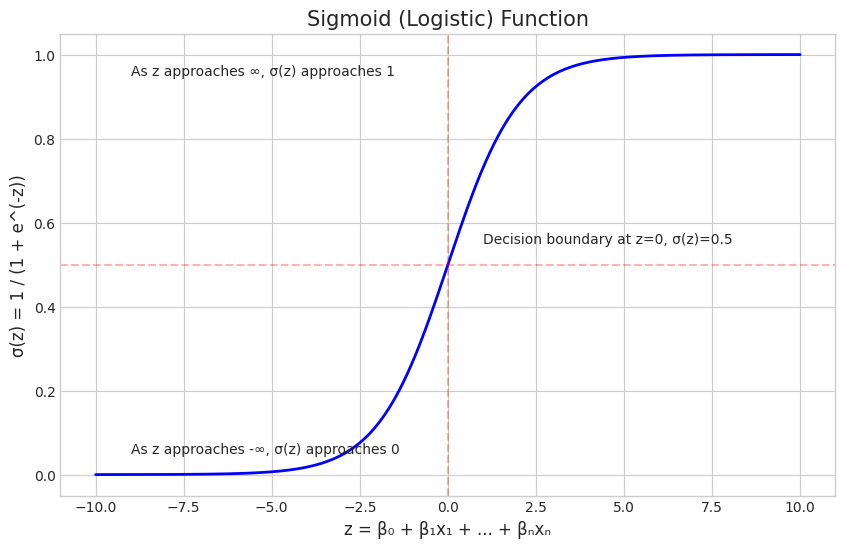

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# Set font to DejaVu Sans globally (or any other that supports subscript glyphs)
mpl.rcParams['font.family'] = 'DejaVu Sans'

# Visualize the sigmoid function
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

x = np.linspace(-10, 10, 1000)
y = sigmoid(x)

plt.figure(figsize=(10, 6))
plt.plot(x, y, 'b-', linewidth=2)
plt.grid(True)
plt.title('Sigmoid (Logistic) Function', fontsize=15)
plt.xlabel('z = β₀ + β₁x₁ + ... + βₙxₙ', fontsize=12)
plt.ylabel('σ(z) = 1 / (1 + e^(-z))', fontsize=12)
plt.axhline(y=0.5, color='r', linestyle='--', alpha=0.3)
plt.axvline(x=0, color='r', linestyle='--', alpha=0.3)
plt.text(-9, 0.95, 'As z approaches ∞, σ(z) approaches 1', fontsize=10)
plt.text(-9, 0.05, 'As z approaches -∞, σ(z) approaches 0', fontsize=10)
plt.text(1, 0.55, 'Decision boundary at z=0, σ(z)=0.5', fontsize=10)
plt.show()

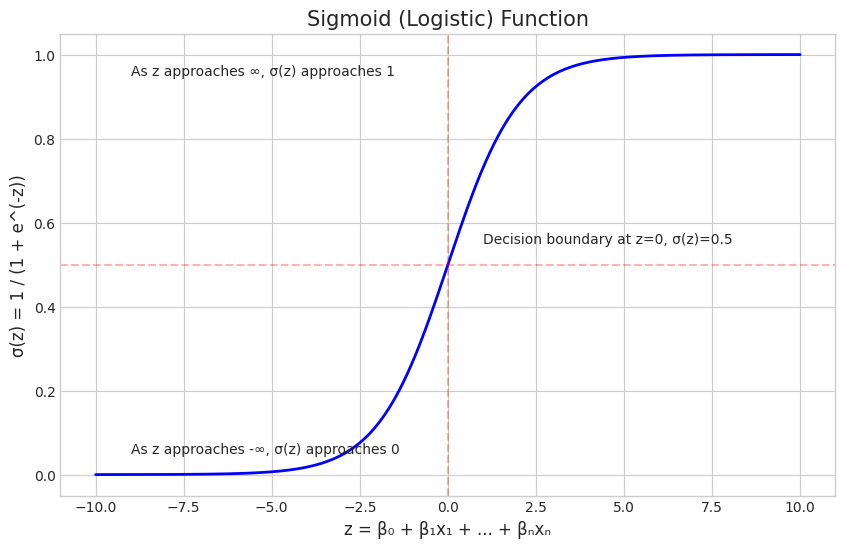

In [5]:
# Updated version with the font set to DejaVu Sans only for this specific plot, which will avoid the missing glyph warnings

import numpy as np
import matplotlib.pyplot as plt

# Visualize the sigmoid function
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

x = np.linspace(-10, 10, 1000)
y = sigmoid(x)

plt.figure(figsize=(10, 6))
plt.rcParams['font.family'] = 'DejaVu Sans'  # Set font only for this plot

plt.plot(x, y, 'b-', linewidth=2)
plt.grid(True)
plt.title('Sigmoid (Logistic) Function', fontsize=15)
plt.xlabel('z = β₀ + β₁x₁ + ... + βₙxₙ', fontsize=12)
plt.ylabel('σ(z) = 1 / (1 + e^(-z))', fontsize=12)
plt.axhline(y=0.5, color='r', linestyle='--', alpha=0.3)
plt.axvline(x=0, color='r', linestyle='--', alpha=0.3)
plt.text(-9, 0.95, 'As z approaches ∞, σ(z) approaches 1', fontsize=10)
plt.text(-9, 0.05, 'As z approaches -∞, σ(z) approaches 0', fontsize=10)
plt.text(1, 0.55, 'Decision boundary at z=0, σ(z)=0.5', fontsize=10)
plt.show()

## 3. Generate Sample Dataset

Let's generate a synthetic dataset for binary classification to demonstrate logistic regression. This dataset will have two features and a binary target variable.

In [6]:
# Set random seed for reproducibility
np.random.seed(42)

# Generate synthetic data for binary classification
n_samples = 500  # Total number of samples

# Create features for the first class
n_class1 = n_samples // 2
X1_class1 = np.random.randn(n_class1, 1) - 2  # centered at -2
X2_class1 = np.random.randn(n_class1, 1) - 2  # centered at -2
y_class1 = np.zeros(n_class1)  # Class 0

# Create features for the second class
n_class2 = n_samples - n_class1
X1_class2 = np.random.randn(n_class2, 1) + 2  # centered at 2
X2_class2 = np.random.randn(n_class2, 1) + 2  # centered at 2
y_class2 = np.ones(n_class2)  # Class 1

# Combine data from both classes
X1 = np.vstack((X1_class1, X1_class2))
X2 = np.vstack((X2_class1, X2_class2))
X = np.hstack((X1, X2))
y = np.hstack((y_class1, y_class2))

# Create a pandas DataFrame for easier handling
df = pd.DataFrame(X, columns=['Feature1', 'Feature2'])
df['Target'] = y

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (500, 3)


,Feature1,Feature2,Target
0,-1.503286,-3.260884,0.0
1,-2.138264,-1.082138,0.0
2,-1.352311,0.122156,0.0
3,-0.476970,-0.967535,0.0
4,-2.234153,-3.519370,0.0


## 4. Exploratory Data Analysis

Let's analyze our synthetic dataset to understand the distribution of features and their relationship with the target variable.

In [7]:
# Display basic information about the dataset
print("Data Information:")
print(f"Total samples: {len(df)}")
print(f"Features: {df.columns[:-1].tolist()}")
print(f"Class distribution: {df['Target'].value_counts().to_dict()}")

# Statistical summary of features
print("\nStatistical Summary:")
df.describe().round(2)

Data Information:
Total samples: 500
Features: ['Feature1', 'Feature2']
Class distribution: {0.0: 250, 1.0: 250}

Statistical Summary:


,Feature1,Feature2,Target
count,500.00,500.00,500.0
mean,-0.03,0.07,0.5
std,2.20,2.28,0.5
min,-4.62,-5.24,0.0
25%,-1.94,-2.00,0.0
50%,-0.06,0.13,0.5
75%,1.95,2.14,1.0
max,4.57,4.63,1.0


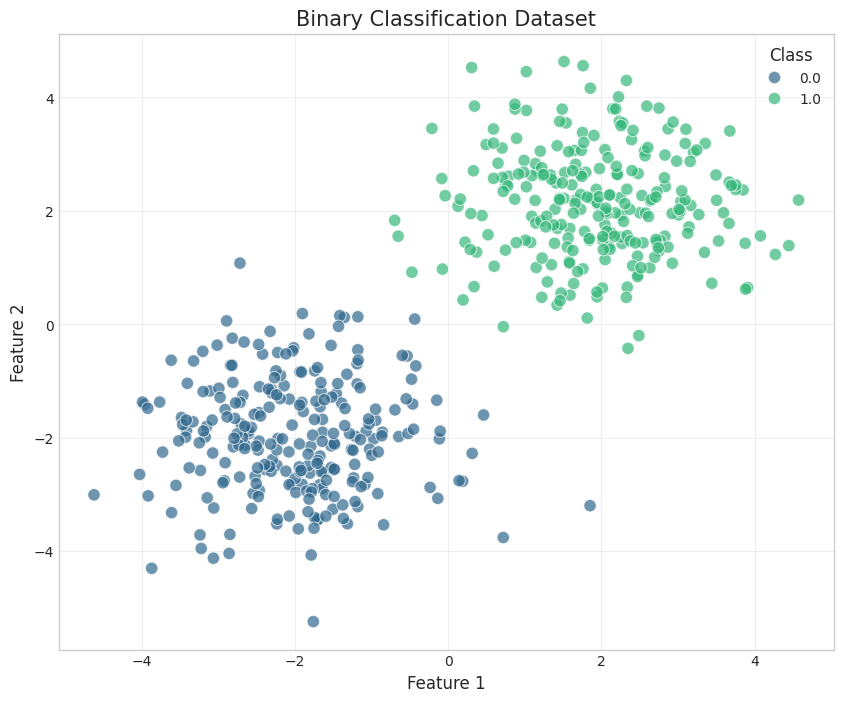

In [8]:
# Visualize the data points and separation between classes
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df, x='Feature1', y='Feature2', hue='Target', palette='viridis', s=80, alpha=0.7)
plt.title('Binary Classification Dataset', fontsize=15)
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.legend(title='Class', title_fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

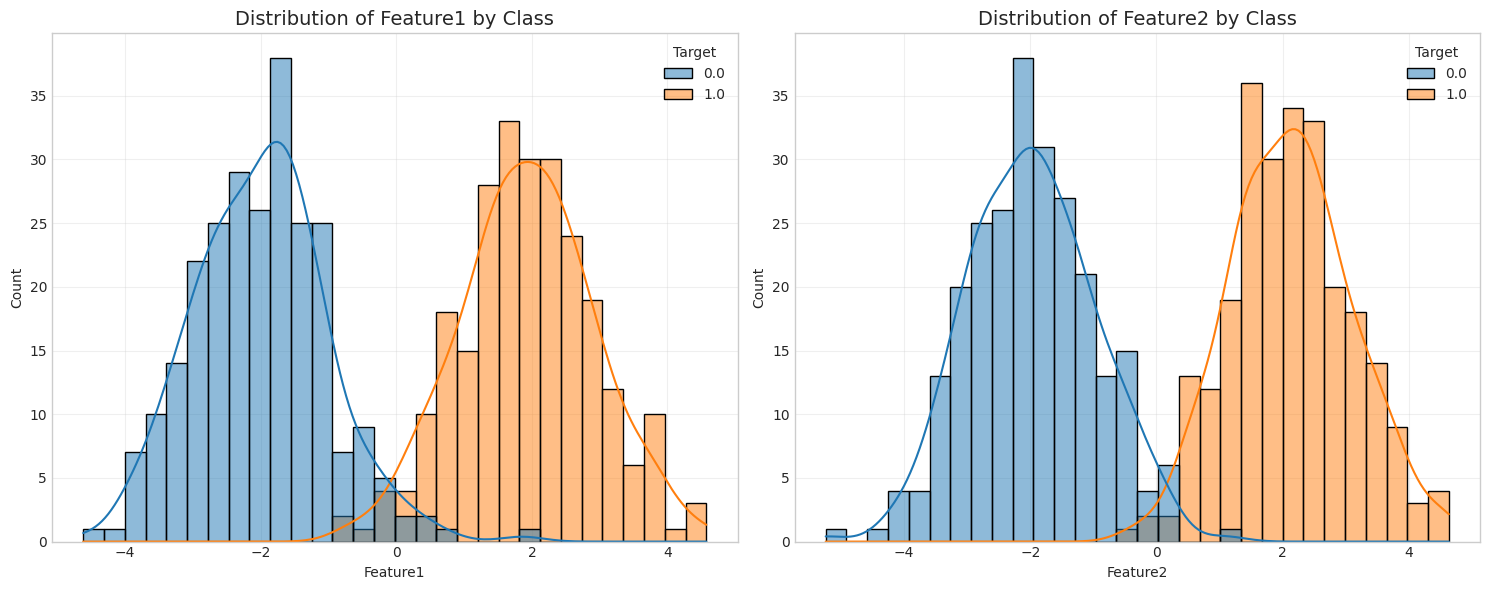

In [9]:
# Distribution of features by class
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for i, feature in enumerate(['Feature1', 'Feature2']):
    sns.histplot(data=df, x=feature, hue='Target', bins=30, kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {feature} by Class', fontsize=14)
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Implement Logistic Regression from Scratch

Before using scikit-learn's implementation, let's implement logistic regression from scratch to understand the underlying mechanics better. We'll implement:

1. Sigmoid function 
2. Cost function (log loss)
3. Gradient descent for parameter optimization
4. Prediction function

In [10]:
class LogisticRegressionFromScratch:
    def __init__(self, learning_rate=0.01, num_iterations=10000):
        self.learning_rate = learning_rate
        self.num_iterations = num_iterations
        self.weights = None
        self.bias = None
        self.cost_history = []
        
    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))
    
    def initialize_parameters(self, n_features):
        self.weights = np.zeros((n_features,))
        self.bias = 0
    
    def compute_cost(self, X, y, weights, bias):
        m = X.shape[0]
        z = np.dot(X, weights) + bias
        h = self.sigmoid(z)
        
        # Clip values to avoid log(0) which is undefined
        epsilon = 1e-15
        h = np.clip(h, epsilon, 1 - epsilon)
        
        # Compute log loss
        cost = -1/m * np.sum(y * np.log(h) + (1 - y) * np.log(1 - h))
        return cost
    
    def compute_gradients(self, X, y, weights, bias):
        m = X.shape[0]
        z = np.dot(X, weights) + bias
        h = self.sigmoid(z)
        
        # Compute gradients
        dw = 1/m * np.dot(X.T, (h - y))
        db = 1/m * np.sum(h - y)
        
        return dw, db
    
    def fit(self, X, y):
        # Initialize parameters
        self.initialize_parameters(X.shape[1])
        
        # Gradient descent
        for i in range(self.num_iterations):
            # Compute gradients
            dw, db = self.compute_gradients(X, y, self.weights, self.bias)
            
            # Update parameters
            self.weights = self.weights - self.learning_rate * dw
            self.bias = self.bias - self.learning_rate * db
            
            # Compute cost and save to history (every 100 iterations to save computation)
            if i % 100 == 0:
                cost = self.compute_cost(X, y, self.weights, self.bias)
                self.cost_history.append(cost)
                
        return self
    
    def predict_proba(self, X):
        z = np.dot(X, self.weights) + self.bias
        return self.sigmoid(z)
    
    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

Training set size: (400, 2)
Testing set size: (100, 2)


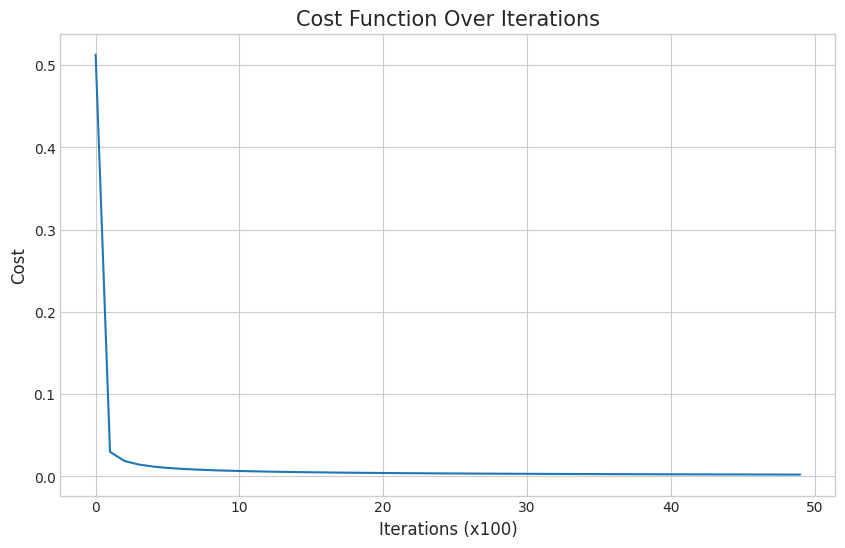

Accuracy of custom logistic regression: 1.0000

Learned Weights: [2.5869612  3.15355298]
Learned Bias: 0.1224538025944226


In [11]:
# Split the data into training and testing sets
X = df[['Feature1', 'Feature2']].values
y = df['Target'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

# Train the model
custom_log_reg = LogisticRegressionFromScratch(learning_rate=0.1, num_iterations=5000)
custom_log_reg.fit(X_train, y_train)

# Plot the cost history
plt.figure(figsize=(10, 6))
plt.plot(custom_log_reg.cost_history)
plt.title('Cost Function Over Iterations', fontsize=15)
plt.xlabel('Iterations (x100)', fontsize=12)
plt.ylabel('Cost', fontsize=12)
plt.grid(True)
plt.show()

# Make predictions
y_pred_custom = custom_log_reg.predict(X_test)

# Calculate accuracy
accuracy_custom = np.mean(y_pred_custom == y_test)
print(f"Accuracy of custom logistic regression: {accuracy_custom:.4f}")

# Print out the learned parameters
print(f"\nLearned Weights: {custom_log_reg.weights}")
print(f"Learned Bias: {custom_log_reg.bias}")

## 6. Using Scikit-learn's LogisticRegression

Now, let's implement logistic regression using scikit-learn's built-in class for comparison.

In [12]:
# Create and train the scikit-learn logistic regression model
sklearn_log_reg = LogisticRegression(random_state=42)
sklearn_log_reg.fit(X_train, y_train)

# Make predictions
y_pred_sklearn = sklearn_log_reg.predict(X_test)
y_pred_prob_sklearn = sklearn_log_reg.predict_proba(X_test)[:, 1]

# Calculate accuracy
accuracy_sklearn = accuracy_score(y_test, y_pred_sklearn)
print(f"Accuracy of scikit-learn logistic regression: {accuracy_sklearn:.4f}")

# Print out the learned parameters
print(f"\nLearned Weights (Coefficients): {sklearn_log_reg.coef_[0]}")
print(f"Learned Bias (Intercept): {sklearn_log_reg.intercept_[0]}")

Accuracy of scikit-learn logistic regression: 1.0000

Learned Weights (Coefficients): [1.79736688 2.14661295]
Learned Bias (Intercept): 0.044080002229973075


## 7. Model Evaluation

Let's evaluate both logistic regression models using various metrics such as:
- Accuracy, Precision, Recall, F1-score
- Confusion Matrix
- ROC Curve and AUC

In [13]:
# Custom model evaluation
y_pred_prob_custom = custom_log_reg.predict_proba(X_test)

# Create evaluation metrics for custom model
cm_custom = confusion_matrix(y_test, y_pred_custom)
precision_custom = precision_score(y_test, y_pred_custom)
recall_custom = recall_score(y_test, y_pred_custom)
f1_custom = f1_score(y_test, y_pred_custom)
fpr_custom, tpr_custom, _ = roc_curve(y_test, y_pred_prob_custom)
auc_custom = roc_auc_score(y_test, y_pred_prob_custom)

# Scikit-learn model metrics
cm_sklearn = confusion_matrix(y_test, y_pred_sklearn)
precision_sklearn = precision_score(y_test, y_pred_sklearn)
recall_sklearn = recall_score(y_test, y_pred_sklearn)
f1_sklearn = f1_score(y_test, y_pred_sklearn)
fpr_sklearn, tpr_sklearn, _ = roc_curve(y_test, y_pred_prob_sklearn)
auc_sklearn = roc_auc_score(y_test, y_pred_prob_sklearn)

# Print metrics comparison
print("--- Model Evaluation Metrics ---")
print(f"{'Metric':<15} {'Custom Model':<15} {'Scikit-learn Model':<15}")
print("-" * 45)
print(f"{'Accuracy':<15} {accuracy_custom:<15.4f} {accuracy_sklearn:<15.4f}")
print(f"{'Precision':<15} {precision_custom:<15.4f} {precision_sklearn:<15.4f}")
print(f"{'Recall':<15} {recall_custom:<15.4f} {recall_sklearn:<15.4f}")
print(f"{'F1-score':<15} {f1_custom:<15.4f} {f1_sklearn:<15.4f}")
print(f"{'AUC':<15} {auc_custom:<15.4f} {auc_sklearn:<15.4f}")

--- Model Evaluation Metrics ---
Metric          Custom Model    Scikit-learn Model
---------------------------------------------
Accuracy        1.0000          1.0000         
Precision       1.0000          1.0000         
Recall          1.0000          1.0000         
F1-score        1.0000          1.0000         
AUC             1.0000          1.0000         


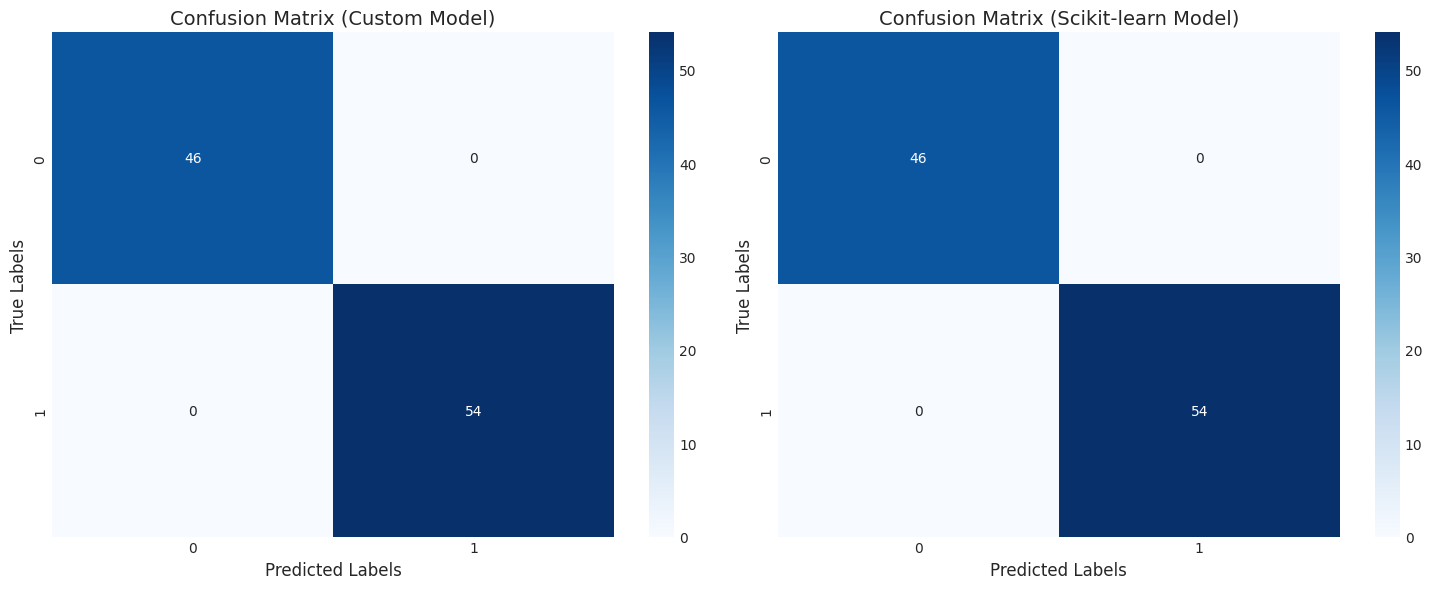

In [14]:
# Plot confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.heatmap(cm_custom, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix (Custom Model)', fontsize=14)
axes[0].set_xlabel('Predicted Labels', fontsize=12)
axes[0].set_ylabel('True Labels', fontsize=12)

sns.heatmap(cm_sklearn, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Confusion Matrix (Scikit-learn Model)', fontsize=14)
axes[1].set_xlabel('Predicted Labels', fontsize=12)
axes[1].set_ylabel('True Labels', fontsize=12)

plt.tight_layout()
plt.show()

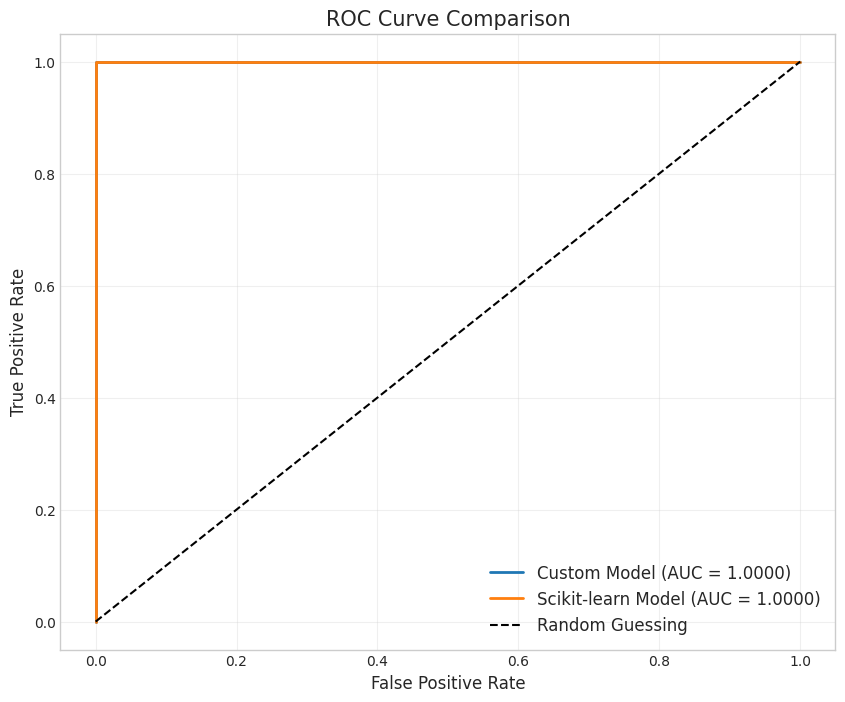

In [15]:
# Plot ROC curves
plt.figure(figsize=(10, 8))
plt.plot(fpr_custom, tpr_custom, label=f'Custom Model (AUC = {auc_custom:.4f})', linewidth=2)
plt.plot(fpr_sklearn, tpr_sklearn, label=f'Scikit-learn Model (AUC = {auc_sklearn:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison', fontsize=15)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

## 8. Visualizing the Decision Boundary

Let's visualize the decision boundary of both logistic regression models on a 2D feature space.

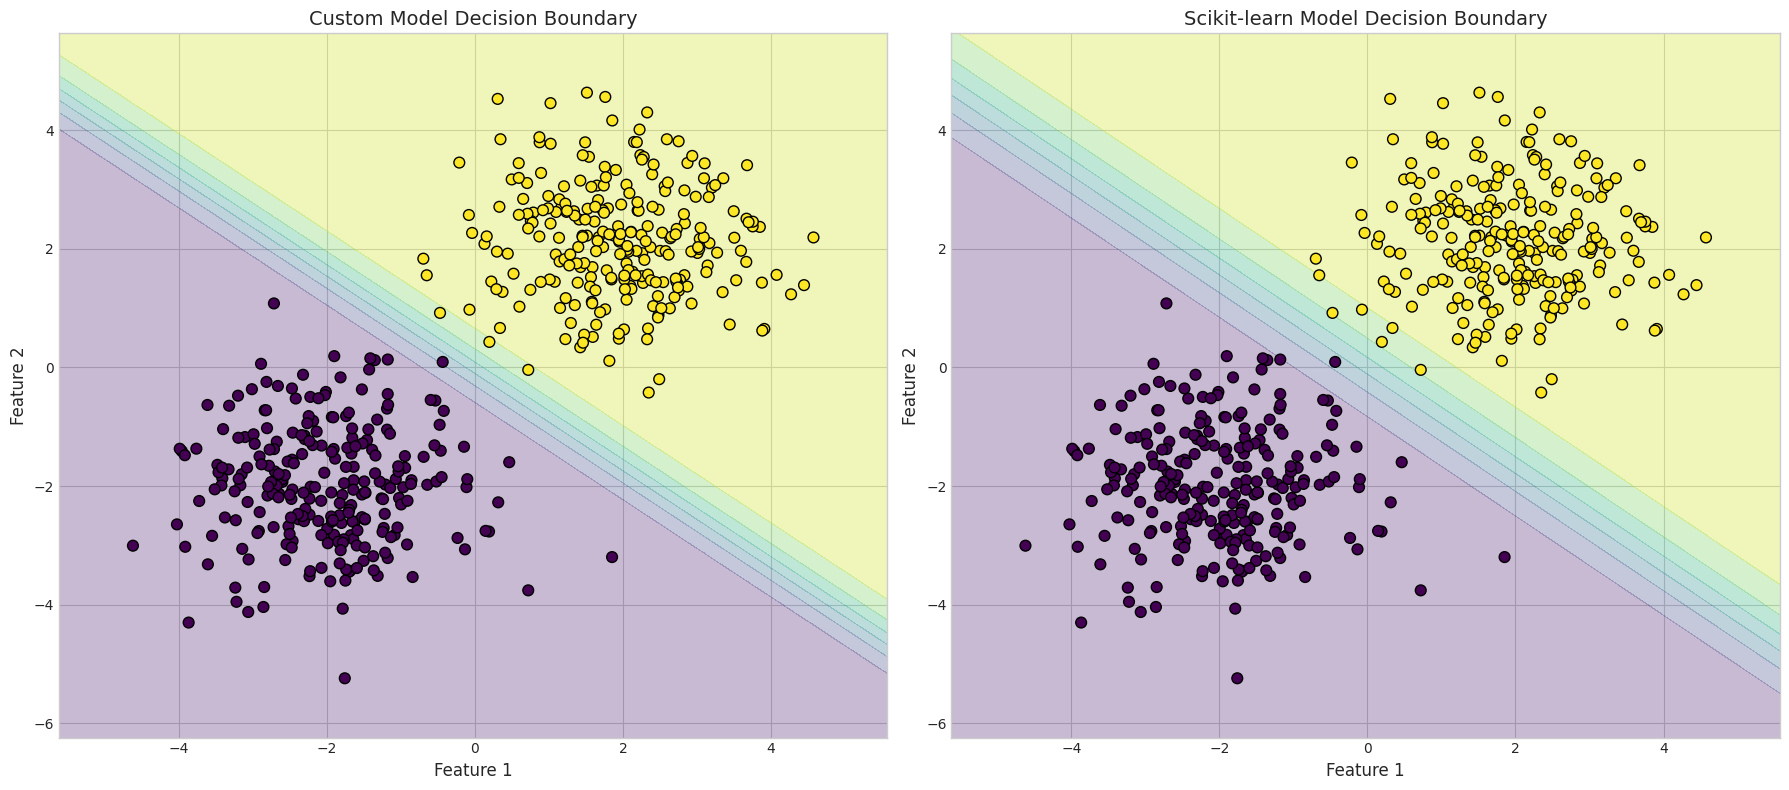

In [16]:
def plot_decision_boundary(model, X, y, model_type="Custom", ax=None):
    if ax is None:
        ax = plt.gca()
        
    # Define the grid
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), 
                          np.linspace(y_min, y_max, 100))
    
    # Get predictions for grid points
    Z = np.c_[xx.ravel(), yy.ravel()]
    
    if model_type == "Custom":
        Z_pred = model.predict_proba(Z)
    else:
        Z_pred = model.predict_proba(Z)[:, 1]
    
    Z_pred = Z_pred.reshape(xx.shape)
    
    # Plot the decision boundary and data points
    ax.contourf(xx, yy, Z_pred, alpha=0.3, cmap='viridis')
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolors='k', s=60)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_title(f'{model_type} Model Decision Boundary', fontsize=14)
    ax.set_xlabel('Feature 1', fontsize=12)
    ax.set_ylabel('Feature 2', fontsize=12)
    
    return ax

# Plot decision boundaries
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

plot_decision_boundary(custom_log_reg, X, y, model_type="Custom", ax=axes[0])
plot_decision_boundary(sklearn_log_reg, X, y, model_type="Scikit-learn", ax=axes[1])

plt.tight_layout()
plt.show()

## 9. Working with Real-world Data

Now, let's apply logistic regression to a real-world dataset - the breast cancer dataset from scikit-learn.

In [17]:
# Load breast cancer dataset
breast_cancer = load_breast_cancer()
X_cancer = breast_cancer.data
y_cancer = breast_cancer.target
feature_names = breast_cancer.feature_names

print(f"Dataset shape: {X_cancer.shape}")
print(f"Number of features: {len(feature_names)}")
print(f"Feature names: {feature_names}")
print(f"Target names: {breast_cancer.target_names}")
print(f"Class distribution: {np.bincount(y_cancer)}")

Dataset shape: (569, 30)
Number of features: 30
Feature names: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']
Target names: ['malignant' 'benign']
Class distribution: [212 357]


In [18]:
# Create a DataFrame for easier handling
cancer_df = pd.DataFrame(X_cancer, columns=feature_names)
cancer_df['target'] = y_cancer

# Display first few rows
cancer_df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.95      0.96        43
      benign       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



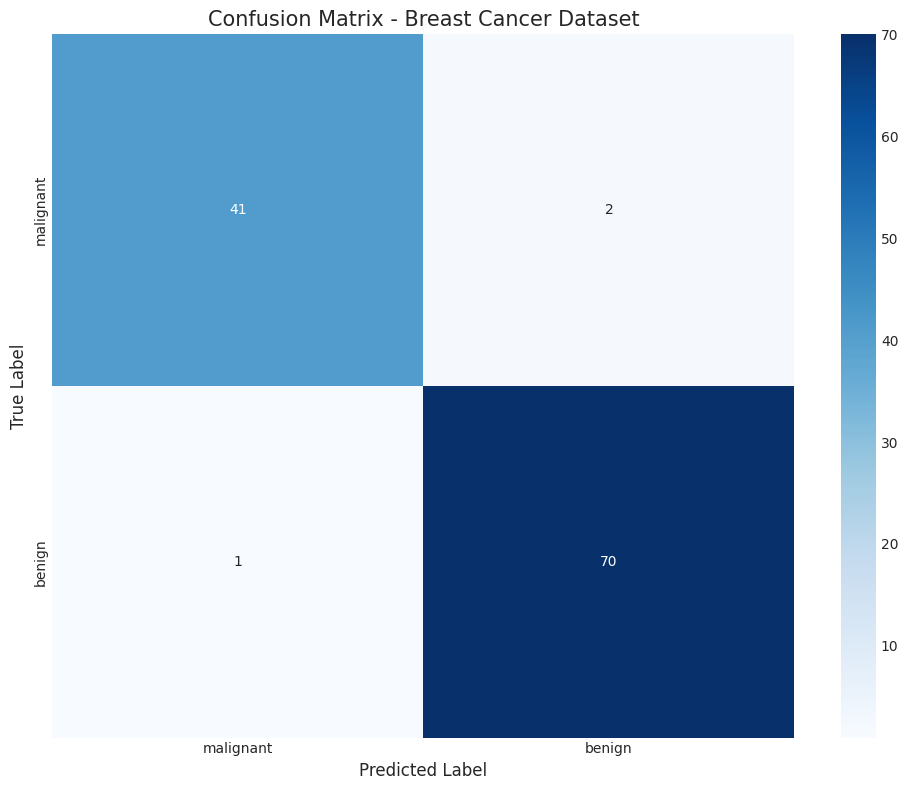

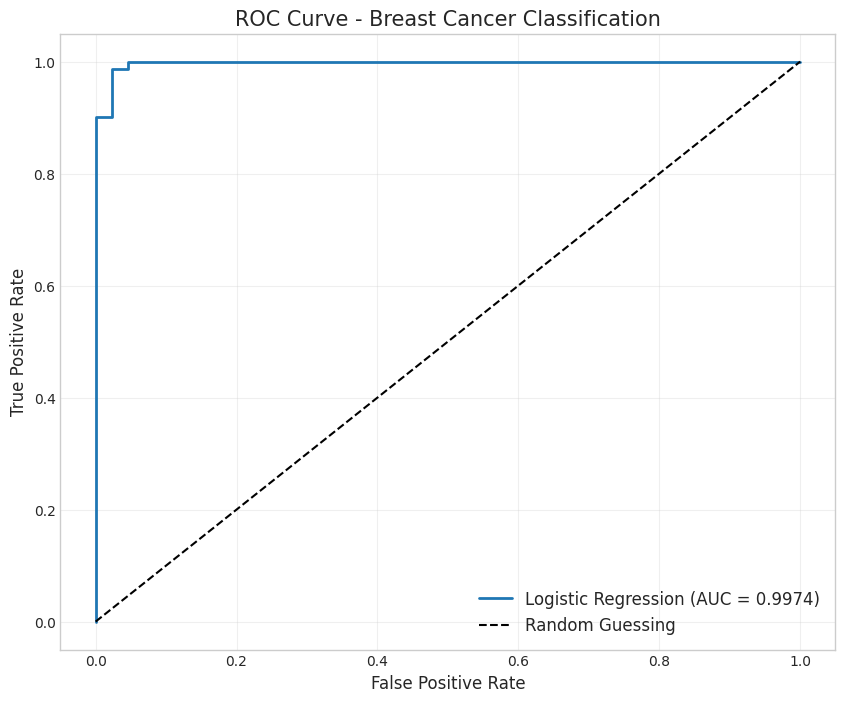

In [19]:
# Split data
X_train_cancer, X_test_cancer, y_train_cancer, y_test_cancer = train_test_split(
    X_cancer, y_cancer, test_size=0.2, random_state=42
)

# Scale features for better performance
scaler = StandardScaler()
X_train_cancer_scaled = scaler.fit_transform(X_train_cancer)
X_test_cancer_scaled = scaler.transform(X_test_cancer)

# Train logistic regression model
cancer_log_reg = LogisticRegression(max_iter=1000, random_state=42)
cancer_log_reg.fit(X_train_cancer_scaled, y_train_cancer)

# Make predictions
y_pred_cancer = cancer_log_reg.predict(X_test_cancer_scaled)
y_pred_prob_cancer = cancer_log_reg.predict_proba(X_test_cancer_scaled)[:, 1]

# Evaluate model
print("Classification Report:")
print(classification_report(y_test_cancer, y_pred_cancer, target_names=breast_cancer.target_names))

# Confusion matrix
cm_cancer = confusion_matrix(y_test_cancer, y_pred_cancer)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_cancer, annot=True, fmt='d', cmap='Blues', 
            xticklabels=breast_cancer.target_names, 
            yticklabels=breast_cancer.target_names)
plt.title('Confusion Matrix - Breast Cancer Dataset', fontsize=15)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

# Plot ROC curve
fpr_cancer, tpr_cancer, _ = roc_curve(y_test_cancer, y_pred_prob_cancer)
auc_cancer = roc_auc_score(y_test_cancer, y_pred_prob_cancer)

plt.figure(figsize=(10, 8))
plt.plot(fpr_cancer, tpr_cancer, label=f'Logistic Regression (AUC = {auc_cancer:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Breast Cancer Classification', fontsize=15)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

## 10. Interpreting Model Coefficients

The coefficients in logistic regression represent the change in log-odds of the outcome for a one-unit increase in the feature. Let's interpret the coefficients from our breast cancer model.

In [20]:
# Get coefficients and their absolute values
coefficients = cancer_log_reg.coef_[0]
abs_coefficients = np.abs(coefficients)

# Create a DataFrame of features and their coefficients
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Absolute Value': abs_coefficients
})

# Sort by absolute value to find most impactful features
coef_df_sorted = coef_df.sort_values('Absolute Value', ascending=False)

print("Top 10 Most Influential Features:")
coef_df_sorted.head(10)

Top 10 Most Influential Features:


,Feature,Coefficient,Absolute Value
21,worst texture,-1.350606,1.350606
10,radius error,-1.268178,1.268178
28,worst symmetry,-1.208200,1.208200
7,mean concave points,-1.119804,1.119804
26,worst concavity,-0.943053,0.943053
13,area error,-0.907186,0.907186
20,worst radius,-0.879840,0.879840
23,worst area,-0.841846,0.841846
6,mean concavity,-0.801458,0.801458
27,worst concave points,-0.778217,0.778217


In [23]:
# # Visualize feature importance
# plt.figure(figsize=(12, 10))
# sns.barplot(x='Coefficient', y='Feature', data=coef_df_sorted.head(10), palette='viridis')
# plt.title('Top 10 Feature Importance in Logistic Regression', fontsize=15)
# plt.xlabel('Coefficient Value (Log-odds)', fontsize=12)
# plt.ylabel('Feature', fontsize=12)
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()

```
FutureWarning: 
Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.
```

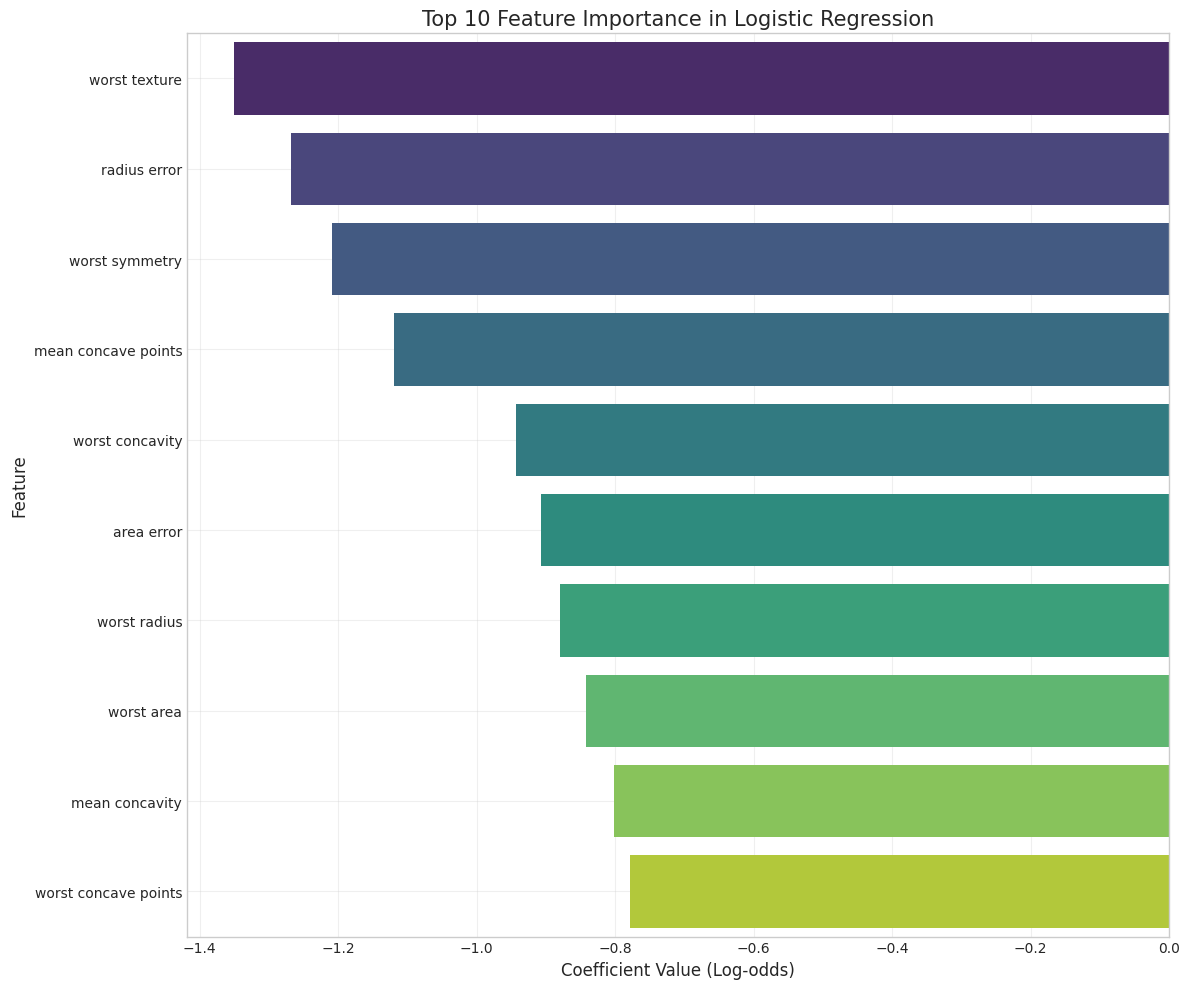

In [24]:
# Visualize feature importance
plt.figure(figsize=(12, 10))
sns.barplot(x='Coefficient', y='Feature', hue='Feature', data=coef_df_sorted.head(10), palette='viridis', legend=False)
plt.title('Top 10 Feature Importance in Logistic Regression', fontsize=15)
plt.xlabel('Coefficient Value (Log-odds)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [25]:
# Calculate and interpret odds ratios
coef_df['Odds Ratio'] = np.exp(coef_df['Coefficient'])
coef_df['% Change in Odds'] = (coef_df['Odds Ratio'] - 1) * 100

# Display odds ratios for top features
coef_odds_sorted = coef_df.sort_values('Absolute Value', ascending=False).head(10)

print("Odds Ratio Interpretation for Top 10 Features:")
coef_odds_sorted[['Feature', 'Coefficient', 'Odds Ratio', '% Change in Odds']]

Odds Ratio Interpretation for Top 10 Features:


,Feature,Coefficient,Odds Ratio,% Change in Odds
21,worst texture,-1.350606,0.259083,-74.091669
10,radius error,-1.268178,0.281344,-71.865628
28,worst symmetry,-1.208200,0.298734,-70.126557
7,mean concave points,-1.119804,0.326344,-67.365627
26,worst concavity,-0.943053,0.389437,-61.056299
13,area error,-0.907186,0.403659,-59.634136
20,worst radius,-0.879840,0.414849,-58.515082
23,worst area,-0.841846,0.430914,-56.908565
6,mean concavity,-0.801458,0.448674,-55.132572
27,worst concave points,-0.778217,0.459224,-54.077604


## Summary

In this notebook, we've covered:

1. The theory behind logistic regression and the sigmoid function
2. Implementation of logistic regression from scratch
3. Using scikit-learn's LogisticRegression implementation
4. Evaluating models using various metrics (accuracy, precision, recall, F1, AUC)
5. Visualizing decision boundaries
6. Working with real-world data (breast cancer dataset)
7. Interpreting model coefficients in terms of log-odds and odds ratios

Logistic regression is a powerful algorithm for binary classification and serves as a foundation for understanding more complex classification algorithms. Despite its simplicity, it often performs well on many real-world problems and provides interpretable results.